  Round   10/60  |  train-logloss: 0.4409
  Round   20/60  |  train-logloss: 0.3615
  Round   30/60  |  train-logloss: 0.3238
  Round   40/60  |  train-logloss: 0.3244
  Round   50/60  |  train-logloss: 0.3281
  Round   60/60  |  train-logloss: 0.3290
Training complete.

Test Accuracy: 0.8500
              precision    recall  f1-score   support

           0       0.76      0.95      0.85        43
           1       0.96      0.77      0.85        57

    accuracy                           0.85       100
   macro avg       0.86      0.86      0.85       100
weighted avg       0.87      0.85      0.85       100



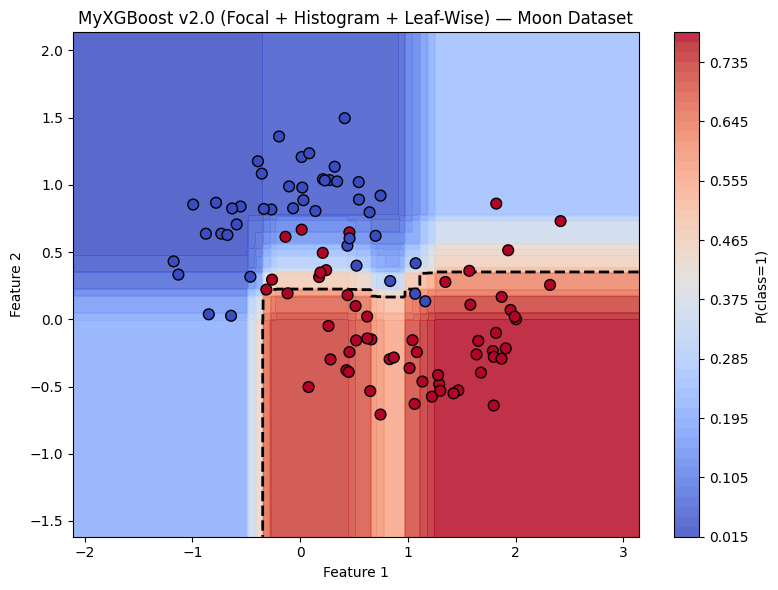

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ════════════════════════════════════════════════════════════════════
#  MyXGBoost v2.0 LIBRARY
#  New: Quantile Regression Loss + Leaf-Wise (Best-First) Tree Growth
# ════════════════════════════════════════════════════════════════════

def _sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


# ── Gradient Functions ──────────────────────────────────────────────

def logloss_gradients(y, F):
    p = _sigmoid(F)
    return p - y, p * (1 - p) + 1e-8


def focal_gradients(y, F, gamma=2.0, alpha=0.25):
    p   = _sigmoid(F)
    eps = 1e-7
    w   = (1 - p + eps) ** gamma          # focal weight
    g   = alpha * w * (p - y)
    h   = alpha * w * p * (1 - p) + eps
    return g, h


def quantile_gradients(y, F, quantile=0.5):
    """
    Pseudo-Huber / pinball gradients for quantile regression.
    - g = -(quantile)      if residual > 0   (under-prediction)
    - g = -(quantile - 1)  if residual <= 0  (over-prediction)
    Hessian is approximated as a small constant (standard XGBoost practice).
    """
    residual = y - F
    g = np.where(residual > 0,
                 -quantile,            # gradient for under-prediction
                 -(quantile - 1.0))    # gradient for over-prediction
    h = np.ones_like(g) * 1e-1        # constant hessian approximation
    return g, h


# ── Histogram Binner ────────────────────────────────────────────────

class HistogramBinner:
    def __init__(self, max_bins=256):
        self.max_bins  = max_bins
        self.bin_edges = []

    def fit_transform(self, X):
        self.bin_edges = []
        X_b = np.zeros_like(X, dtype=np.int32)
        for i in range(X.shape[1]):
            edges = np.histogram_bin_edges(X[:, i], bins=self.max_bins)
            self.bin_edges.append(edges)
            X_b[:, i] = np.clip(np.digitize(X[:, i], edges[1:-1]), 0, self.max_bins - 1)
        return X_b

    def transform(self, X):
        X_b = np.zeros_like(X, dtype=np.int32)
        for i, edges in enumerate(self.bin_edges):
            X_b[:, i] = np.clip(np.digitize(X[:, i], edges[1:-1]), 0, self.max_bins - 1)
        return X_b


# ── Leaf Node ───────────────────────────────────────────────────────

class _Leaf:
    """Represents a candidate or final leaf during leaf-wise growth."""
    def __init__(self, indices, g, h, depth, lambda_reg, gamma_split):
        self.indices      = indices         # sample indices in this node
        self.g            = g
        self.h            = h
        self.depth        = depth
        self.lambda_reg   = lambda_reg
        self.gamma_split  = gamma_split
        self.G            = g.sum()
        self.H            = h.sum()
        self.leaf_value   = -self.G / (self.H + lambda_reg)
        # best split info (populated by find_best_split)
        self.best_gain    = 0.0
        self.best_feat    = None
        self.best_bin     = None
        self.left_idx     = None
        self.right_idx    = None

    def _score(self, g, h):
        return g**2 / (h + self.lambda_reg)

    def find_best_split(self, X_b, min_child_weight):
        """Scan all features/bins and record the best split."""
        G, H = self.G, self.H
        for f in range(X_b.shape[1]):
            vals = X_b[self.indices, f]
            n_bins = vals.max() + 1
            gh_hist = np.zeros((n_bins, 2))
            np.add.at(gh_hist[:, 0], vals, self.g)
            np.add.at(gh_hist[:, 1], vals, self.h)
            g_cum = np.cumsum(gh_hist[:, 0])
            h_cum = np.cumsum(gh_hist[:, 1])

            for b in range(n_bins - 1):
                g_l, h_l = g_cum[b], h_cum[b]
                g_r, h_r = G - g_l, H - h_l
                if h_l < min_child_weight or h_r < min_child_weight:
                    continue
                gain = (0.5 * (self._score(g_l, h_l)
                                + self._score(g_r, h_r)
                                - self._score(G, H))
                        - self.gamma_split)
                if gain > self.best_gain:
                    self.best_gain = gain
                    self.best_feat = f
                    self.best_bin  = b
                    lm = vals <= b
                    self.left_idx  = self.indices[lm]
                    self.right_idx = self.indices[~lm]


# ── Leaf-Wise XGBoost Tree ──────────────────────────────────────────

class LeafWiseXGBTree:
    """
    Leaf-Wise (Best-First) Growth:
    Instead of expanding ALL leaves at a given depth (level-wise),
    we always split the single leaf with the highest gain first.
    This mirrors LightGBM's strategy and can achieve lower loss
    with fewer leaves, but may overfit more on small datasets.

    Controlled by `num_leaves` (max leaves) rather than `max_depth`.
    An optional `max_depth` guard prevents extremely deep single branches.
    """

    def __init__(self, num_leaves=31, max_depth=None,
                 lambda_reg=1.0, gamma=0.0, min_child_weight=1.0):
        self.num_leaves       = num_leaves
        self.max_depth        = max_depth       # optional depth cap
        self.lambda_reg       = lambda_reg
        self.gamma            = gamma
        self.min_child_weight = min_child_weight
        # Stored as a list of (feature, bin_threshold, left_child, right_child)
        # or leaf value; indexed by node id
        self._nodes = {}   # node_id -> dict

    def fit(self, X_b, g, h):
        n = len(g)
        # Root node
        root = _Leaf(np.arange(n), g, h, depth=0,
                     lambda_reg=self.lambda_reg, gamma_split=self.gamma)
        root.find_best_split(X_b, self.min_child_weight)

        active_leaves  = [root]   # candidate leaves (can be split)
        final_leaves   = []       # leaves that won't be split further
        leaf_count     = 1        # we start with 1 leaf (the root)

        while leaf_count < self.num_leaves and active_leaves:
            # Pick the leaf with highest gain
            active_leaves.sort(key=lambda l: l.best_gain, reverse=True)
            best = active_leaves[0]

            # Stop if no profitable split exists
            if best.best_gain <= 0:
                break

            # Respect optional max_depth guard
            if self.max_depth is not None and best.depth >= self.max_depth:
                final_leaves.append(active_leaves.pop(0))
                continue

            active_leaves.pop(0)

            # Create two child leaves
            lm = best.left_idx
            rm = best.right_idx

            left_child = _Leaf(lm, g[lm], h[lm],
                               depth=best.depth + 1,
                               lambda_reg=self.lambda_reg,
                               gamma_split=self.gamma)
            right_child = _Leaf(rm, g[rm], h[rm],
                                depth=best.depth + 1,
                                lambda_reg=self.lambda_reg,
                                gamma_split=self.gamma)

            left_child.find_best_split(X_b, self.min_child_weight)
            right_child.find_best_split(X_b, self.min_child_weight)

            # Record the split in node dict
            node_id = id(best)
            self._nodes[node_id] = {
                'type':    'split',
                'feature': best.best_feat,
                'bin':     best.best_bin,
                'left':    left_child,
                'right':   right_child,
            }

            active_leaves.append(left_child)
            active_leaves.append(right_child)
            leaf_count += 1          # one split -> one extra leaf

        # All remaining active leaves become final leaves
        for leaf in active_leaves:
            final_leaves.append(leaf)

        # Mark all final leaves in node dict
        for leaf in final_leaves:
            self._nodes[id(leaf)] = {
                'type':  'leaf',
                'value': leaf.leaf_value,
            }

        self._root = root

    def _predict_one_node(self, node, X_b):
        nid = id(node)
        info = self._nodes[nid]
        if info['type'] == 'leaf':
            return np.full(X_b.shape[0], info['value'])
        # split node
        lm  = X_b[:, info['feature']] <= info['bin']
        out = np.zeros(X_b.shape[0])
        if lm.any():
            out[lm]  = self._predict_one_node(info['left'],  X_b[lm])
        if (~lm).any():
            out[~lm] = self._predict_one_node(info['right'], X_b[~lm])
        return out

    def predict(self, X_b):
        return self._predict_one_node(self._root, X_b)


# ── Main Library Class ──────────────────────────────────────────────

class MyXGBoostClassifier:
    """
    MyXGBoost v2.0
    ─────────────────────────────────────────────────────────────────
    Features:
      ✔ Histogram Binning (HistogramBinner)
      ✔ Focal Loss  ('focal')
      ✔ Log Loss    ('logloss')
      ✔ Quantile Regression ('quantile')  ← NEW
      ✔ Leaf-Wise (Best-First) Tree Growth ← NEW

    Parameters
    ──────────
    loss            : 'logloss' | 'focal' | 'quantile'
    quantile        : float in (0,1), only used when loss='quantile'
    growth_policy   : 'depthwise' | 'lossguide'  (lossguide = leaf-wise)
    num_leaves      : max leaves per tree (leaf-wise mode)
    max_depth       : max depth per tree (depthwise mode, optional cap in lossguide)
    """

    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=4, num_leaves=31,
                 lambda_reg=1.0, gamma=0.0,
                 loss='focal',
                 focal_gamma=2.0, focal_alpha=0.25,
                 quantile=0.5,
                 growth_policy='lossguide',   # 'depthwise' | 'lossguide'
                 max_bins=256, min_child_weight=1.0,
                 verbose=10):
        self.n_estimators     = n_estimators
        self.eta              = learning_rate
        self.max_depth        = max_depth
        self.num_leaves       = num_leaves
        self.lambda_reg       = lambda_reg
        self.gamma            = gamma
        self.loss             = loss
        self.focal_gamma      = focal_gamma
        self.focal_alpha      = focal_alpha
        self.quantile         = quantile
        self.growth_policy    = growth_policy
        self.max_bins         = max_bins
        self.min_child_weight = min_child_weight
        self.verbose          = verbose
        self.trees            = []
        self.binner           = HistogramBinner(max_bins)
        self.base_pred        = 0.0

    def _grad(self, y, F):
        if self.loss == 'focal':
            return focal_gradients(y, F, self.focal_gamma, self.focal_alpha)
        if self.loss == 'quantile':
            return quantile_gradients(y, F, self.quantile)
        return logloss_gradients(y, F)

    def _build_tree(self):
        if self.growth_policy == 'lossguide':
            return LeafWiseXGBTree(
                num_leaves=self.num_leaves,
                max_depth=self.max_depth,
                lambda_reg=self.lambda_reg,
                gamma=self.gamma,
                min_child_weight=self.min_child_weight,
            )
        # depthwise: use the original HistXGBTree
        return HistXGBTree(
            max_depth=self.max_depth,
            lambda_reg=self.lambda_reg,
            gamma=self.gamma,
            min_child_weight=self.min_child_weight,
        )

    def fit(self, X, y):
        p0 = np.clip(np.mean(y), 1e-7, 1 - 1e-7)
        self.base_pred = np.log(p0 / (1 - p0))
        F   = np.full(len(y), self.base_pred)
        X_b = self.binner.fit_transform(X)

        for t in range(self.n_estimators):
            g, h = self._grad(y, F)
            tree = self._build_tree()
            tree.fit(X_b, g, h)
            F += self.eta * tree.predict(X_b)
            self.trees.append(tree)
            if self.verbose and (t + 1) % self.verbose == 0:
                p    = _sigmoid(F)
                loss = -np.mean(y * np.log(p + 1e-7) + (1-y) * np.log(1-p+1e-7))
                print(f'  Round {t+1:>4}/{self.n_estimators}  |  train-logloss: {loss:.4f}')
        print('Training complete.')
        return self

    def predict_proba(self, X):
        X_b = self.binner.transform(X)
        F   = np.full(X_b.shape[0], self.base_pred)
        for tree in self.trees:
            F += self.eta * tree.predict(X_b)
        return _sigmoid(F)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


# ── Original HistXGBTree (depth-wise, kept for depthwise policy) ────

class HistXGBTree:
    def __init__(self, max_depth=4, lambda_reg=1.0, gamma=0.0, min_child_weight=1.0):
        self.max_depth        = max_depth
        self.lambda_reg       = lambda_reg
        self.gamma            = gamma
        self.min_child_weight = min_child_weight
        self.left = self.right = None
        self.split_feature = self.split_threshold = self.leaf_value = None

    def _gain(self, g_l, h_l, g_r, h_r, G, H):
        s = lambda g, h: g**2 / (h + self.lambda_reg)
        return 0.5 * (s(g_l, h_l) + s(g_r, h_r) - s(G, H)) - self.gamma

    def fit(self, X_b, g, h, depth=0):
        G, H = np.sum(g), np.sum(h)
        if depth == self.max_depth or len(g) < 2 or H < self.min_child_weight:
            self.leaf_value = -G / (H + self.lambda_reg)
            return

        best_gain = 0
        for f in range(X_b.shape[1]):
            n_bins  = X_b[:, f].max() + 1
            gh_hist = np.zeros((n_bins, 2))
            np.add.at(gh_hist[:, 0], X_b[:, f], g)
            np.add.at(gh_hist[:, 1], X_b[:, f], h)
            g_cum, h_cum = np.cumsum(gh_hist[:, 0]), np.cumsum(gh_hist[:, 1])

            for b in range(n_bins - 1):
                g_l, h_l = g_cum[b], h_cum[b]
                g_r, h_r = G - g_l, H - h_l
                if h_l < self.min_child_weight or h_r < self.min_child_weight:
                    continue
                gain = self._gain(g_l, h_l, g_r, h_r, G, H)
                if gain > best_gain:
                    best_gain, self.split_feature, self.split_threshold = gain, f, b

        if best_gain > 0:
            lm = X_b[:, self.split_feature] <= self.split_threshold
            self.left  = HistXGBTree(self.max_depth, self.lambda_reg,
                                     self.gamma, self.min_child_weight)
            self.right = HistXGBTree(self.max_depth, self.lambda_reg,
                                     self.gamma, self.min_child_weight)
            self.left.fit(X_b[lm],  g[lm],  h[lm],  depth + 1)
            self.right.fit(X_b[~lm], g[~lm], h[~lm], depth + 1)
        else:
            self.leaf_value = -G / (H + self.lambda_reg)

    def predict(self, X_b):
        if self.leaf_value is not None:
            return np.full(X_b.shape[0], self.leaf_value)
        out = np.zeros(X_b.shape[0])
        lm  = X_b[:, self.split_feature] <= self.split_threshold
        if lm.any():    out[lm]  = self.left.predict(X_b[lm])
        if (~lm).any(): out[~lm] = self.right.predict(X_b[~lm])
        return out


# ════════════════════════════════════════════════════════════════════
#  USE LIBRARY ON MOON DATASET
# ════════════════════════════════════════════════════════════════════

X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

clf = MyXGBoostClassifier(
    n_estimators  = 60,
    learning_rate = 0.15,
    max_depth     = 6,          # used as depth cap inside leaf-wise growth
    num_leaves    = 31,         # leaf-wise: max 31 leaves per tree
    lambda_reg    = 1.0,
    gamma         = 0.1,
    loss          = 'focal',    # try 'quantile' for regression tasks
    focal_gamma   = 2.0,
    growth_policy = 'lossguide',  # ← leaf-wise growth
    max_bins      = 64,
    verbose       = 10,
)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
print(f'\nTest Accuracy: {accuracy_score(y_test, preds):.4f}')
print(classification_report(y_test, preds))

# ── Plot ─────────────────────────────────────────────────────────────
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.85)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm',
           edgecolors='k', s=60, zorder=3)
plt.colorbar(cf, ax=ax, label='P(class=1)')
ax.set_title('MyXGBoost v2.0 (Focal + Histogram + Leaf-Wise) — Moon Dataset', fontsize=12)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

Training done — 30 trees built.
Test Accuracy: 0.9600


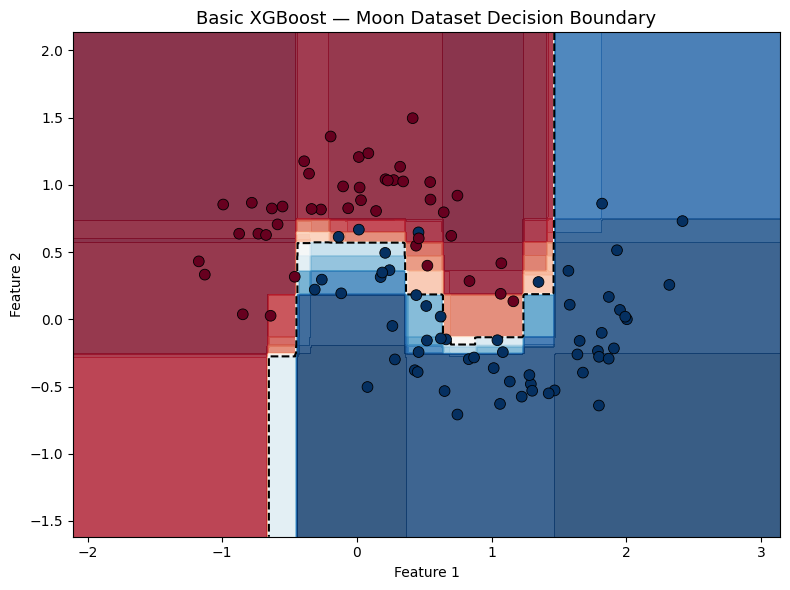

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Basic XGBoost — Moon Dataset
# Built from scratch: proper trees, gradient/hessian splits, sigmoid output.

# ── Tree Node ──────────────────────────────────────────────────────────────────
class XGBoostTree:
    def __init__(self, max_depth=3, lambda_reg=1.0, gamma=0.0, min_child_weight=1.0):
        self.max_depth       = max_depth
        self.lambda_reg      = lambda_reg
        self.gamma           = gamma
        self.min_child_weight= min_child_weight
        self.left = self.right = None
        self.split_feature = self.split_threshold = self.leaf_value = None

    def _gain(self, g_l, h_l, g_r, h_r, g, h):
        s = lambda gs, hs: gs**2 / (hs + self.lambda_reg)
        return 0.5 * (s(g_l, h_l) + s(g_r, h_r) - s(g, h)) - self.gamma

    def fit(self, X, g, h, depth=0):
        if depth == self.max_depth or len(g) < 2 or np.sum(h) < self.min_child_weight:
            self.leaf_value = -np.sum(g) / (np.sum(h) + self.lambda_reg)
            return

        best_gain, G, H = 0, np.sum(g), np.sum(h)
        for f in range(X.shape[1]):
            for thr in np.unique(X[:, f]):
                lm = X[:, f] <= thr
                rm = ~lm
                if not lm.any() or not rm.any(): continue
                g_l, h_l = np.sum(g[lm]), np.sum(h[lm])
                g_r, h_r = np.sum(g[rm]), np.sum(h[rm])
                if h_l < self.min_child_weight or h_r < self.min_child_weight: continue
                gain = self._gain(g_l, h_l, g_r, h_r, G, H)
                if gain > best_gain:
                    best_gain, self.split_feature, self.split_threshold = gain, f, thr

        if best_gain > 0:
            lm = X[:, self.split_feature] <= self.split_threshold
            self.left  = XGBoostTree(self.max_depth, self.lambda_reg, self.gamma, self.min_child_weight)
            self.right = XGBoostTree(self.max_depth, self.lambda_reg, self.gamma, self.min_child_weight)
            self.left.fit(X[lm], g[lm], h[lm], depth + 1)
            self.right.fit(X[~lm], g[~lm], h[~lm], depth + 1)
        else:
            self.leaf_value = -G / (H + self.lambda_reg)

    def predict(self, X):
        if self.leaf_value is not None:
            return np.full(X.shape[0], self.leaf_value)
        out = np.zeros(X.shape[0])
        lm  = X[:, self.split_feature] <= self.split_threshold
        if lm.any():  out[lm]  = self.left.predict(X[lm])
        if (~lm).any(): out[~lm] = self.right.predict(X[~lm])
        return out

# ── Classifier ────────────────────────────────────────────────────────────────
class BasicXGBoostClassifier:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3,
                 lambda_reg=1.0, gamma=0.0):
        self.n_estimators  = n_estimators
        self.eta           = learning_rate
        self.max_depth     = max_depth
        self.lambda_reg    = lambda_reg
        self.gamma         = gamma
        self.trees         = []
        self.base_pred     = None

    def _sigmoid(self, x): return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

    def fit(self, X, y):
        p0 = np.mean(y)
        self.base_pred = np.log(p0 / (1 - p0 + 1e-8))
        F = np.full(len(y), self.base_pred)
        for t in range(self.n_estimators):
            p = self._sigmoid(F)
            g, h = p - y, p * (1 - p)
            tree = XGBoostTree(self.max_depth, self.lambda_reg, self.gamma)
            tree.fit(X, g, h)
            F += self.eta * tree.predict(X)
            self.trees.append(tree)
        print(f'Training done — {self.n_estimators} trees built.')

    def predict_proba(self, X):
        F = np.full(X.shape[0], self.base_pred)
        for tree in self.trees:
            F += self.eta * tree.predict(X)
        return self._sigmoid(F)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# ── Data & Train ────────────────────────────────────────────────────────────────
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = BasicXGBoostClassifier(n_estimators=30, learning_rate=0.2, max_depth=3)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, preds):.4f}')

# ── Decision Boundary Plot ─────────────────────────────────────────────────────
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.8)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5, linestyles='--')
ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', edgecolors='k',
           linewidths=0.6, s=60, zorder=3)
ax.set_title('Basic XGBoost — Moon Dataset Decision Boundary', fontsize=13)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()